# Credit Risk ECL Engine — Notebook Executivo

Motor de **Perda Esperada de Crédito (ECL)** conforme **IFRS 9 / Resolução CMN 4.966/2021**:
PD, LGD, EAD, staging (Stage 1/2/3), simulação de Monte Carlo com **correlação entre
segmentos via cópula Gaussiana**, validação estatística e stress testing.

Este notebook executa o pipeline completo (`src/cloud/pipeline.py`) sobre o dataset
real **UCI German Credit** (1.000 contratos) e gera todas as tabelas e gráficos usados
nos relatórios de `reports/`.

> Rode as células em ordem (Kernel → Restart & Run All para reproduzir do zero).


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Executa o pipeline completo

Carga de dados → PD (champion/challenger) → staging IFRS 9 → LGD/EAD → ECL → simulação com cópula → validação → stress test → auditoria.

In [2]:
from src.cloud.pipeline import run_pipeline

result = run_pipeline(
    data_source="csv",
    data_path=str(project_root / "data/raw/german_credit.csv"),
    n_simulations=10000,
    inter_segment_correlation=0.25,
    asset_correlation=0.15,
    verbose=True,
)

df_ecl = result.pop("df_ecl")


[1/9] Dados carregados: 1000 contratos (fonte: csv)
[2/9] Pré-processamento: 40 atributos, split 750/250 (treino/teste)


[3/9] PD — Logistic Gini=0.617 | GBM Gini=0.595 → champion: logistic_regression
[4/9] Staging IFRS 9 — Stage1=245 Stage2=455 Stage3=300
[5/9] LGD médio=49.6% | EAD total=R$ 2,289,880.60
[6/9] ECL total=R$ 874,913.67 | Coverage ratio=38.21%


[7/9] Monte Carlo c/ cópula (10000 cenários) — EL=874,570.34 | VaR99.9=1,026,556.20 | Benefício diversificação=295.19
[8/9] Validação — Gini=0.617 KS=0.531 PSI=0.0259 (estável)
[9/9] Stress test concluído (4 cenários)


## 2. Resumo executivo

In [3]:
portfolio = result["portfolio"]
mc = result["monte_carlo"]
val = result["validation"]

print(f"Modelo campeão      : {result['pd_models']['champion']}")
print(f"Gini / KS            : {val['gini']:.3f} / {val['ks']:.3f}")
print(f"PSI                  : {val['psi']:.4f} ({val['psi_rating']})")
print(f"Exposição total (EAD): R$ {portfolio['total_exposure']:,.2f}")
print(f"ECL total            : R$ {portfolio['total_ecl']:,.2f}")
print(f"Coverage ratio       : {portfolio['coverage_ratio']:.2%}")
print(f"VaR 95% / 99.9%      : R$ {mc['var']['var_95']:,.2f} / R$ {mc['var']['var_99.9']:,.2f}")
print(f"CVaR 95% / 99.9%     : R$ {mc['cvar']['cvar_95']:,.2f} / R$ {mc['cvar']['cvar_99.9']:,.2f}")
print(f"Benefício diversif.  : R$ {mc['diversification_benefit']:,.2f}")


Modelo campeão      : logistic_regression
Gini / KS            : 0.617 / 0.531
PSI                  : 0.0259 (estável)
Exposição total (EAD): R$ 2,289,880.60
ECL total            : R$ 874,913.67
Coverage ratio       : 38.21%
VaR 95% / 99.9%      : R$ 956,175.22 / R$ 1,026,556.20
CVaR 95% / 99.9%     : R$ 976,174.43 / R$ 1,037,848.15
Benefício diversif.  : R$ 295.19


## 3. Comparação champion vs. challenger (PD)

In [4]:
pd_models_df = pd.DataFrame(result["pd_models"]).drop(index=[]).T if False else pd.DataFrame({
    "modelo": ["logistic_regression", "gradient_boosting"],
    "gini": [result["pd_models"]["logistic_regression"]["gini"], result["pd_models"]["gradient_boosting"]["gini"]],
    "ks": [result["pd_models"]["logistic_regression"]["ks"], result["pd_models"]["gradient_boosting"]["ks"]],
    "auc": [result["pd_models"]["logistic_regression"]["auc"], result["pd_models"]["gradient_boosting"]["auc"]],
})
pd_models_df


,modelo,gini,ks,auc
0,logistic_regression,0.62,0.53,0.81
1,gradient_boosting,0.59,0.49,0.80


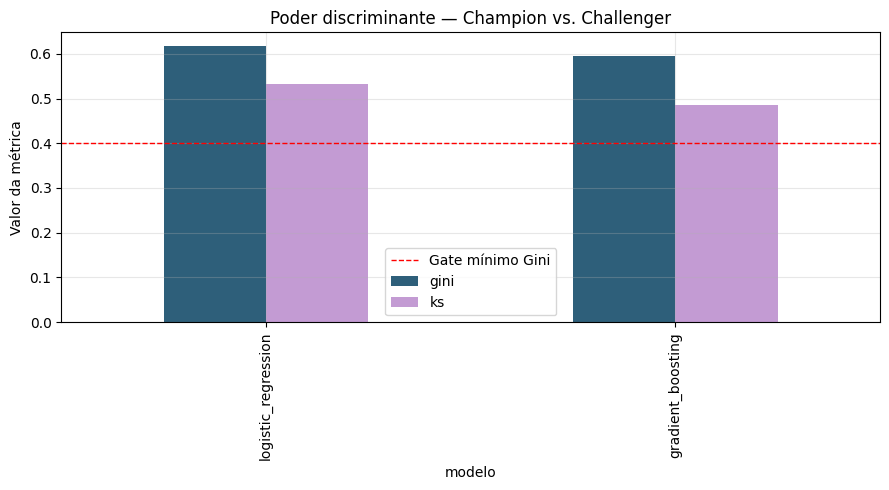

In [5]:
fig, ax = plt.subplots()
pd_models_df.set_index("modelo")[["gini", "ks"]].plot(kind="bar", ax=ax, color=["#2e5f7a", "#c39bd3"])
ax.set_title("Poder discriminante — Champion vs. Challenger")
ax.set_ylabel("Valor da métrica")
ax.axhline(0.40, color="red", linestyle="--", linewidth=1, label="Gate mínimo Gini")
ax.legend()
plt.tight_layout()
plt.show()


## 4. ECL por Stage IFRS 9

In [6]:
stage_df = pd.DataFrame(result["ecl_by_stage"])
stage_df


,stage,n_contracts,total_exposure,avg_pd,avg_lgd,total_ecl,coverage_ratio
0,1,245,"425,092.50",0.11,0.45,"21,403.99",0.05
1,2,455,"1,037,781.50",0.62,0.50,"393,953.91",0.38
2,3,300,"827,006.60",1.00,0.53,"459,555.77",0.56


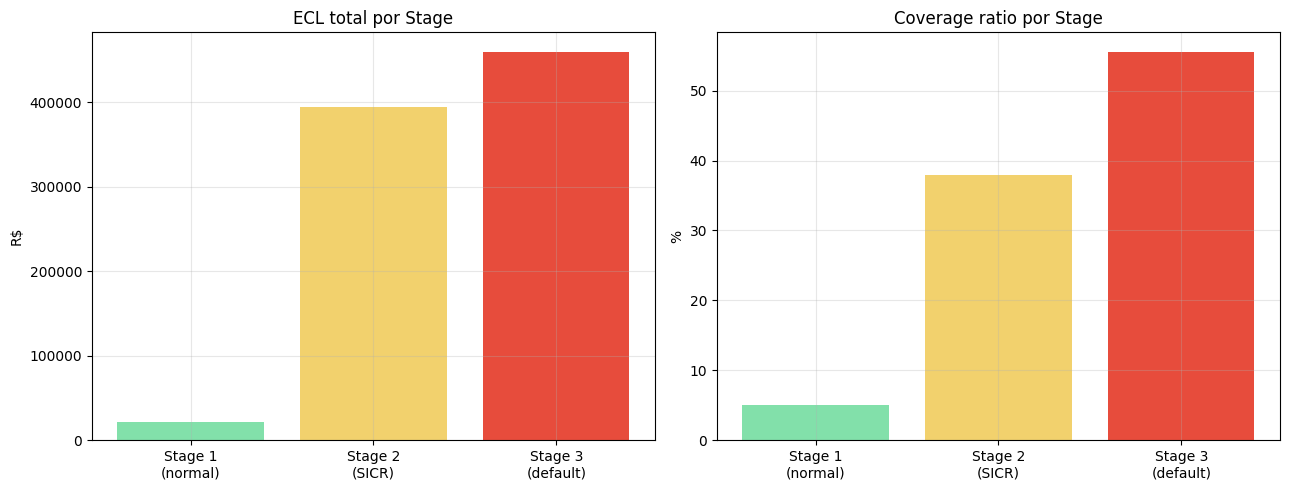

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stage_labels = {1: "Stage 1\n(normal)", 2: "Stage 2\n(SICR)", 3: "Stage 3\n(default)"}
colors = ["#82e0aa", "#f2d16d", "#e74c3c"]

axes[0].bar([stage_labels[s] for s in stage_df["stage"]], stage_df["total_ecl"], color=colors)
axes[0].set_title("ECL total por Stage")
axes[0].set_ylabel("R$")

axes[1].bar([stage_labels[s] for s in stage_df["stage"]], stage_df["coverage_ratio"] * 100, color=colors)
axes[1].set_title("Coverage ratio por Stage")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()


## 5. ECL por segmento de portfólio

In [8]:
segment_df = pd.DataFrame(result["ecl_by_segment"]).sort_values("total_ecl", ascending=False)
segment_df


,segment,n_contracts,total_exposure,total_ecl,coverage_ratio
0,bens_consumo,485,"957,709.20","342,965.17",0.36
3,veiculos,337,"888,916.70","332,642.10",0.37
1,pessoal,169,"435,657.60","198,067.69",0.45
2,pj_capital_giro,9,"7,597.10","1,238.71",0.16


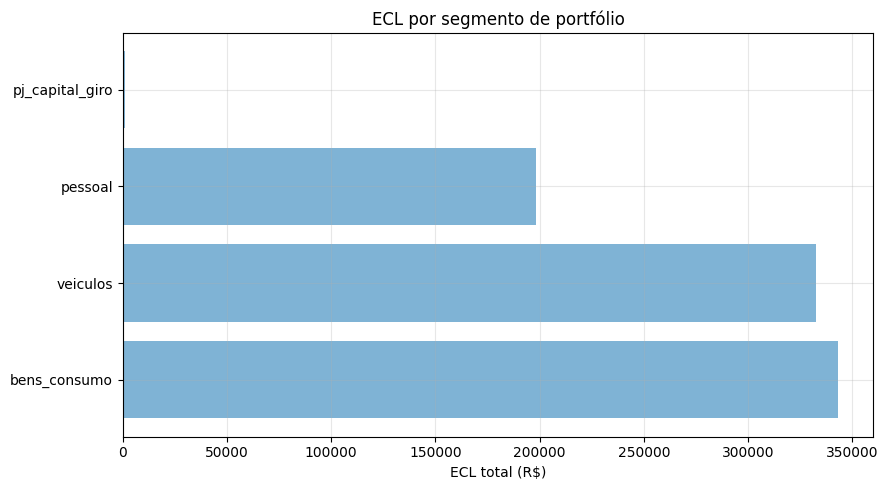

In [9]:
fig, ax = plt.subplots()
ax.barh(segment_df["segment"], segment_df["total_ecl"], color="#7fb3d5")
ax.set_xlabel("ECL total (R$)")
ax.set_title("ECL por segmento de portfólio")
plt.tight_layout()
plt.show()


## 6. Simulação de Monte Carlo com cópula Gaussiana

Distribuição de perda agregada da carteira sob 10.000 cenários correlacionados
entre segmentos (mistura de Vasicek). A linha tracejada marca a ECL contábil
pontual (hipótese de independência); a área além do VaR 99,9% é o risco de
cauda que a provisão contábil não captura.

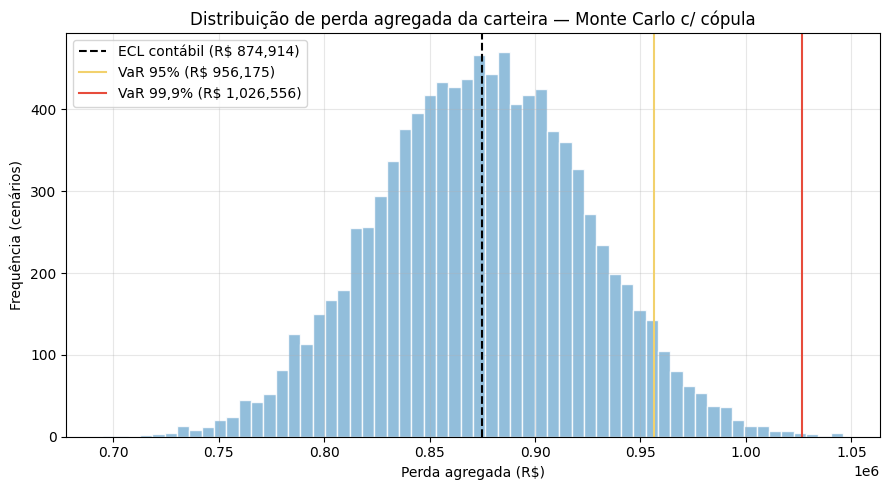

In [10]:
from src.simulation.copula_simulation import simulate_portfolio_losses

sim = simulate_portfolio_losses(
    df_ecl,
    n_simulations=10000,
    inter_segment_correlation=0.25,
    asset_correlation=0.15,
)

fig, ax = plt.subplots()
ax.hist(sim.losses, bins=60, color="#7fb3d5", edgecolor="white", alpha=0.85)
ax.axvline(portfolio["total_ecl"], color="black", linestyle="--", label=f"ECL contábil (R$ {portfolio['total_ecl']:,.0f})")
ax.axvline(sim.var["var_95"], color="#f2d16d", linestyle="-", label=f"VaR 95% (R$ {sim.var['var_95']:,.0f})")
ax.axvline(sim.var["var_99.9"], color="#e74c3c", linestyle="-", label=f"VaR 99,9% (R$ {sim.var['var_99.9']:,.0f})")
ax.set_title("Distribuição de perda agregada da carteira — Monte Carlo c/ cópula")
ax.set_xlabel("Perda agregada (R$)")
ax.set_ylabel("Frequência (cenários)")
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
sim.correlation_matrix.style.background_gradient(cmap="Purples", vmin=0, vmax=1).format("{:.2f}")


,bens_consumo,pessoal,pj_capital_giro,veiculos
bens_consumo,1.00,0.25,0.25,0.25
pessoal,0.25,1.00,0.25,0.25
pj_capital_giro,0.25,0.25,1.00,0.25
veiculos,0.25,0.25,0.25,1.00


## 7. Calibração do modelo de PD

Compara a PD média prevista com a taxa de default observada, por decil de score.

In [12]:
calib_df = pd.DataFrame(result["validation"]["calibration_table"])
calib_df


,decile,n,pd_media_prevista,taxa_default_observada,desvio_absoluto
0,0,25,0.06,0.00,0.06
1,1,25,0.13,0.16,0.03
2,2,25,0.19,0.08,0.11
3,3,25,0.28,0.08,0.20
4,4,25,0.37,0.12,0.25
5,5,25,0.48,0.36,0.12
6,6,25,0.59,0.36,0.23
7,7,25,0.69,0.56,0.13
8,8,25,0.77,0.60,0.17
9,9,25,0.89,0.68,0.21


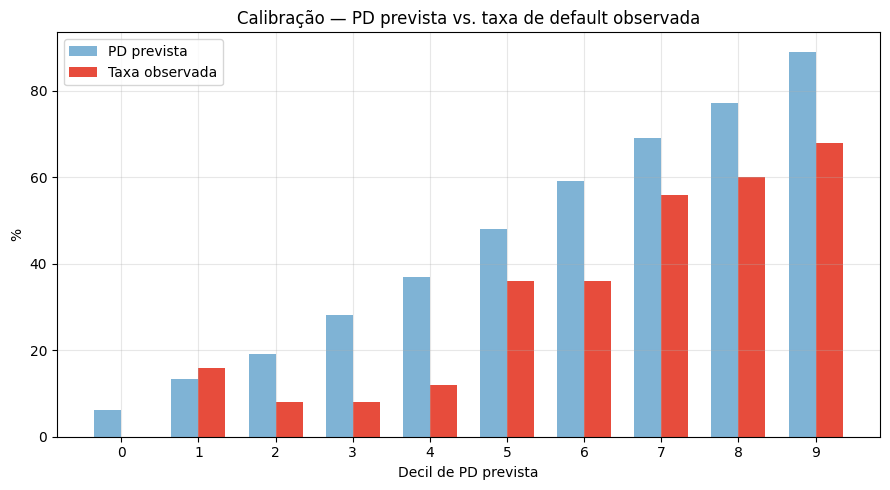

In [13]:
fig, ax = plt.subplots()
x = np.arange(len(calib_df))
width = 0.35
ax.bar(x - width/2, calib_df["pd_media_prevista"] * 100, width, label="PD prevista", color="#7fb3d5")
ax.bar(x + width/2, calib_df["taxa_default_observada"] * 100, width, label="Taxa observada", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(calib_df["decile"])
ax.set_xlabel("Decil de PD prevista")
ax.set_ylabel("%")
ax.set_title("Calibração — PD prevista vs. taxa de default observada")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Backtesting (Teste de Kupiec / POF) por Stage

**Atenção**: ver interpretação crítica em `reports/assumptions.md` — o teste em corte transversal único não é conclusivo sobre calibração para os Stages 1 e 2 (limitação estrutural do dataset, documentada e não ocultada).

In [14]:
backtest_df = pd.DataFrame(result["validation"]["backtesting"])
backtest_df[["stage", "n_observations", "n_defaults", "observed_default_rate", "predicted_pd", "lr_statistic", "p_value", "reject_h0", "conclusion"]]


,stage,n_observations,n_defaults,observed_default_rate,predicted_pd,lr_statistic,p_value,reject_h0,conclusion
0,1,245,0,0.00,0.11,54.88,0.00,True,Modelo REJEITADO no backtesting (PD prevista d...
1,2,455,0,0.00,0.62,872.26,0.00,True,Modelo REJEITADO no backtesting (PD prevista d...
2,3,300,300,1.00,1.00,-0.00,1.00,False,Modelo ACEITO no backtesting (PD prevista comp...


## 9. Stress Testing

Sensibilidade da provisão a choques macroeconômicos (aumento de PD e LGD downturn).

In [15]:
stress_df = pd.DataFrame(result["stress_test"])
stress_df[["label", "total_ecl", "coverage_ratio", "ecl_delta_vs_base", "ecl_delta_pct"]]


,label,total_ecl,coverage_ratio,ecl_delta_vs_base,ecl_delta_pct
0,Cenário Base,"874,913.67",0.38,0.00,0.00
1,"Estresse Moderado (+30% PD, +5pp LGD)","1,016,529.63",0.44,"141,615.96",0.16
2,"Estresse Severo (+80% PD, +12pp LGD)","1,225,578.15",0.54,"350,664.48",0.40
3,"Estresse Extremo (+150% PD, +20pp LGD)","1,409,522.26",0.62,"534,608.59",0.61


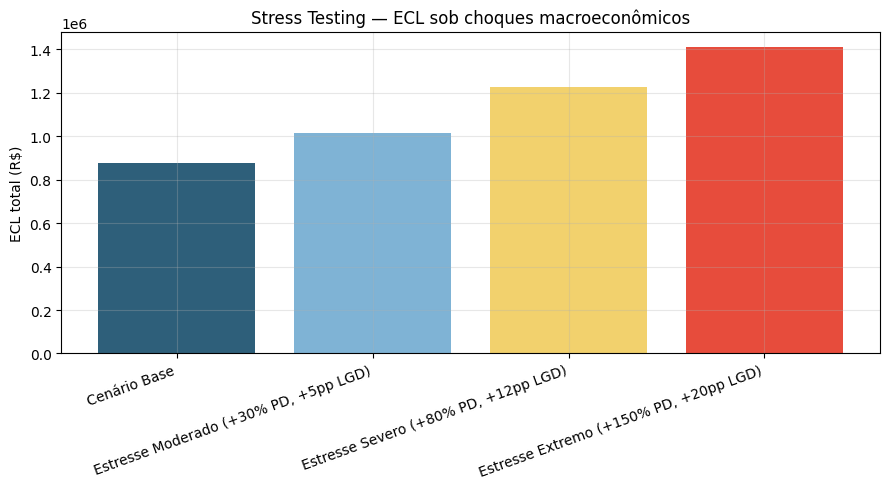

In [16]:
fig, ax = plt.subplots()
colors_stress = ["#2e5f7a", "#7fb3d5", "#f2d16d", "#e74c3c"]
ax.bar(stress_df["label"], stress_df["total_ecl"], color=colors_stress)
ax.set_ylabel("ECL total (R$)")
ax.set_title("Stress Testing — ECL sob choques macroeconômicos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 10. Trilha de auditoria (últimas etapas registradas)

In [17]:
audit_df = pd.DataFrame(result["audit_log"])[["timestamp", "step", "status"]]
audit_df


,timestamp,step,status
0,2026-09-14T21:49:00.585109+00:00,load_data,OK
1,2026-09-14T21:49:00.607788+00:00,preprocess,OK
2,2026-09-14T21:49:01.321945+00:00,train_pd_models,OK
3,2026-09-14T21:49:01.330027+00:00,staging,OK
4,2026-09-14T21:49:01.331193+00:00,lgd_ead,OK
5,2026-09-14T21:49:01.352417+00:00,ecl_calculation,OK
6,2026-09-14T21:49:04.707248+00:00,monte_carlo_copula,OK
7,2026-09-14T21:49:04.718146+00:00,validation,OK
8,2026-09-14T21:49:04.735015+00:00,stress_test,OK
9,2026-09-14T21:49:04.735015+00:00,pipeline_complete,OK


## 11. Exporta resultados

In [18]:
import json

reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

export = {**result, "monte_carlo": {**result["monte_carlo"]}}
with open(reports_dir / "result_final.json", "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2, ensure_ascii=False, default=str)

processed_dir = project_root / "data/processed"
processed_dir.mkdir(parents=True, exist_ok=True)
df_ecl.to_csv(processed_dir / "portfolio_ecl_scored.csv", index=False)

print("Exportado:")
print(f" - {reports_dir / 'result_final.json'}")
print(f" - {processed_dir / 'portfolio_ecl_scored.csv'}")


Exportado:
 - G:\Outros computadores\Meu computador\Controle Base\Projetos, Robos e Automação\Projetos Git\Projetos Extras (Portfolio)\IFRS17\credit-risk-ecl-engine\reports\result_final.json
 - G:\Outros computadores\Meu computador\Controle Base\Projetos, Robos e Automação\Projetos Git\Projetos Extras (Portfolio)\IFRS17\credit-risk-ecl-engine\data\processed\portfolio_ecl_scored.csv


---
## Conclusão

O pipeline completo — dados reais → PD → staging IFRS 9 → LGD/EAD → ECL →
simulação com cópula (correlação) → validação → stress test → auditoria —
roda de ponta a ponta a partir deste notebook. Ver `README.md` e
`reports/` para a documentação completa de metodologia, premissas e
alinhamento regulatório.